In [115]:
import pandas as pd

In [116]:
hapfm = pd.read_csv('../../grenenet_reads/average_seedmix_p0.txt',sep = '\t', header=None)

In [117]:
hapfm.columns = ['chrom', 'pos', 'freq_hapfm']

In [118]:
K = "k21"

In [119]:
import pandas as pd
from pathlib import Path

BASE = Path("/home/tbellagio/scratch/pang/test_freqk/seedmix")

SAMPLES = [f"S{i}" for i in range(1, 9)]

rows = []

for s in SAMPLES:
    print(s)
    work = BASE / "results" / s / K

    # --- index (chrom/pos) ---
    idx_path = work / f"{s}.{K}.freqk.ref_index"
    idx = pd.read_csv(idx_path, header=None)[[1,2]]

    idx.columns = ["chrom", "pos"]
    idx["chrom"] = idx["chrom"].astype(str)
    idx["pos"] = idx["pos"].astype(int) + 2   # keep your +2 correction

    # --- freqk allele frequencies ---
    af_path = work / f"{s}.allele_frequencies.{K}.dedup.tsv"
    af = pd.read_csv(
        af_path,
        sep=r"|",
        header=None,
        names=["ref_freq", "alt_freq"],
        dtype=str,

    )

    # combine by row order
    one = pd.concat([idx.reset_index(drop=True),
                     af],
                    axis=1)

    one["sample"] = s
    rows.append(one)

# long table: one row per (variant_row, sample)
long = pd.concat(rows, ignore_index=True)



S1
S2
S3
S4
S5
S6
S7
S8


In [ ]:
long['alt_freq'] = long['alt_freq'].astype(float)

# mean alt freq across samples per position
mean_alt = (
    long.groupby(["chrom", "pos"], as_index=False)
        .agg(
            alt_freq_mean=("alt_freq", "mean"),
            alt_freq_sd=("alt_freq", "std")
        )
)


mean_alt['chrom'] = mean_alt['chrom'].astype(int)

In [123]:
final = hapfm.merge(mean_alt, on =['chrom', 'pos'])

In [124]:
final.to_csv(f'benchmarked_{K}_freqk_seedmix_hapfm.csv',index=None)

OVERALL: n=2,133,250  corr=0.9473  R^2=0.8974


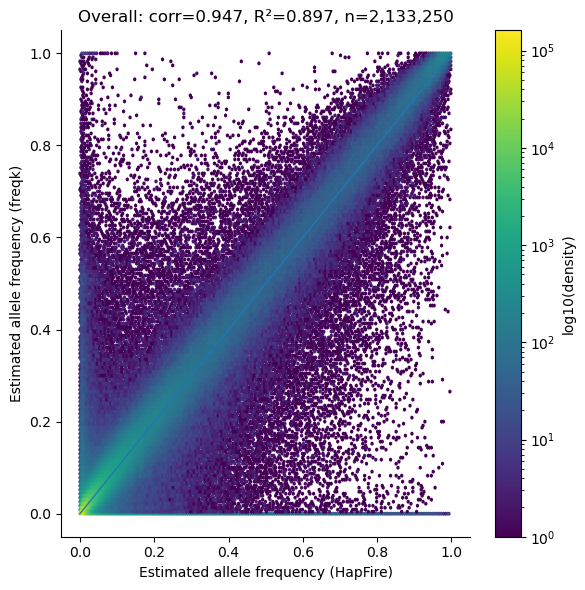

In [125]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = final.copy()
df["chrom"] = df["chrom"].astype(str)
xcol, ycol = "freq_hapfm", "alt_freq_mean"
df[xcol] = pd.to_numeric(df[xcol], errors="coerce")
df[ycol] = pd.to_numeric(df[ycol], errors="coerce")
df = df.dropna(subset=[xcol, ycol])

def corr_r2(x, y):
    x = np.asarray(x); y = np.asarray(y)
    if len(x) < 2:
        return np.nan, np.nan
    r = np.corrcoef(x, y)[0, 1]
    return r, r**2

r_all, r2_all = corr_r2(df[xcol], df[ycol])
print(f"OVERALL: n={len(df):,}  corr={r_all:.4f}  R^2={r2_all:.4f}")

fig, ax = plt.subplots(figsize=(6, 6))

hb = ax.hexbin(
    df[xcol], df[ycol],
    gridsize=200,          # tweak: higher -> finer
    mincnt=1,
    bins="log",             # log-density coloring
    cmap="viridis"
)

ax.plot([0, 1], [0, 1], linewidth=1)

ax.set_xlabel("Estimated allele frequency (HapFire)")
ax.set_ylabel("Estimated allele frequency (freqk)")
ax.set_title(f"Overall: corr={r_all:.3f}, R²={r2_all:.3f}, n={len(df):,}")

# remove top/right spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# optional colorbar (comment out if you don't want it)
cb = fig.colorbar(hb, ax=ax)
cb.set_label("log10(density)")

plt.tight_layout()
plt.savefig(f'benchmark_freqk_seedmix_{K}.png')
plt.show()


In [ ]:
# ---- per chromosome ----
# sort chroms nicely if they are numeric
chroms = sorted(df["chrom"].unique(), key=lambda c: int(c) if c.isdigit() else c)

for c in chroms:
    g = df[df["chrom"] == c]
    r, r2 = corr_r2(g[xcol], g[ycol])
    print(f"Chr {c}: n={len(g):,}  corr={r:.4f}  R^2={r2:.4f}")

    plt.figure(figsize=(6, 6))
    plt.scatter(g[xcol], g[ycol], s=3, alpha=0.2)
    plt.plot([0, 1], [0, 1], linewidth=1)
    plt.xlabel(xcol)
    plt.ylabel(ycol)
    plt.title(f"Chr {c}: corr={r:.3f}, R²={r2:.3f}, n={len(g):,}")
    plt.tight_layout()
    plt.show()


In [88]:
1753028 /3235480

0.5418138885111328

In [18]:
#pd.read_csv('results/S1/k31/S1.k31.freqk.var_index', header=None)